# Decision Tree Model Implementation
This notebook implements a Decision Tree model for the dataset. It includes data loading, model training, evaluation, and visualization of the decision tree.

In [34]:
# Import necessary libraries
import os
import pandas as pd
import geopandas as gpd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree
from dotenv import load_dotenv
from pathlib import Path



Pfad muss ich noch so anpassen, dass der Pfad nur noch \datei beinhaltet und somit Lars auch drauf zugreifen kann

In [8]:

# Load the dataset
# Working Directory prüfen
cwd = Path.cwd()
print(f"Working Directory: {cwd}")

# Versuche .env im aktuellen oder übergeordneten Verzeichnis zu finden
env_path = None
for possible_path in [Path(".env"), Path("../.env"), cwd / ".env", cwd.parent / ".env"]:
    if possible_path.exists():
        env_path = possible_path
        print(f"✓ .env gefunden at: {env_path}")
        break

if env_path:
    load_dotenv(dotenv_path=env_path)
else:
    print("✗ Keine .env Datei gefunden!")

print("Data_path:", os.getenv("Data_path"))

data_base_path = os.getenv("Data_path")

data_file = Path(data_base_path) / "merged_gebaeude_gruendach_solar.shp"
data = gpd.read_file(data_file)


Working Directory: c:\Users\User\Documents\Uni\Master_Bauing\WiSe25_26\AI_in_Human_Water\berlin-green-roofs\notebooks
✓ .env gefunden at: ..\.env
Data_path: C:\\Users\\User\\Documents\\Uni\\Master_Bauing\\WiSe25_26\\AI_in_Human_Water\\berlin-green-roofs\\data


In [35]:
# =====================================================
# SCHRITT 1: FIX - Lade Daten neu und kodiere KORREKT
# =====================================================
print("="*70)
print("PROBLEM FIX: gruendach ist ALLES 0 weil Kodierung falsch ist")
print("="*70)

# Lade Original-Daten aus Shapefile
print(f"\nLade Original-Daten aus: {data_file}")
data_original = gpd.read_file(data_file)
print(f"Größe: {data_original.shape}")

# Schaue auf die Original-Werte
print(f"\nOriginale gruendach-Werte:")
print(data_original['gruendach'].value_counts())

# KORREKTE KODIERUNG: 'vorhanden' = 1, 'nicht vorhanden' = 0
print("\n" + "="*70)
print("KORREKTE KODIERUNG: vorhanden=1, nicht vorhanden=0")
print("="*70)

data_original['gruendach'] = (data_original['gruendach'] == 'vorhanden').astype(int)

print(f"\nNach Kodierung:")
print(data_original['gruendach'].value_counts())
print(f"\n✓ gruendach korrekt kodiert:")
print(f"  1 (vorhanden): {(data_original['gruendach'] == 1).sum()}")
print(f"  0 (nicht vorhanden): {(data_original['gruendach'] == 0).sum()}")

# Nutze die neu geladenen Daten
data = data_original.copy()

PROBLEM FIX: gruendach ist ALLES 0 weil Kodierung falsch ist

Lade Original-Daten aus: C:\Users\User\Documents\Uni\Master_Bauing\WiSe25_26\AI_in_Human_Water\berlin-green-roofs\data\merged_gebaeude_gruendach_solar.shp
Größe: (530758, 17)

Originale gruendach-Werte:
gruendach
nicht vorhanden    508789
vorhanden           16897
Name: count, dtype: int64

KORREKTE KODIERUNG: vorhanden=1, nicht vorhanden=0

Nach Kodierung:
gruendach
0    513861
1     16897
Name: count, dtype: int64

✓ gruendach korrekt kodiert:
  1 (vorhanden): 16897
  0 (nicht vorhanden): 513861


In [37]:
# WICHTIG: Prüfe die Kodierung der gruendach-Spalte
print("="*70)
print("ANALYSE GRUENDACH-SPALTE:")
print("="*70)

# data wurde bereits kodiert, aber schaue auf die VALUE COUNTS
print("\nWert-Verteilung nach bisheriger Kodierung:")
print(data['gruendach'].value_counts())

# Step 1: Target-Spalte verwenden wie sie ist
target_col = "gruendach"
X = data.drop(columns=[target_col]).copy()
y = data[target_col].copy()

# y ist bereits 0/1 kodiert, aber ALL 0!
y_encoded = y.values  # Einfach verwenden wie es ist

print(f"\ny_encoded distribution: {pd.Series(y_encoded).value_counts()}")

# Step 2: Nur numerische Features verwenden
X_numeric = X.select_dtypes(include=["number"]).copy()
print(f"\nFeatures: {X_numeric.columns.tolist()}")

# Step 3: Fehlende Werte füllen
X_numeric = X_numeric.fillna(X_numeric.median(numeric_only=True))
print(f"NaN nach fillna: {X_numeric.isna().sum().sum()}")

# Step 4: Train/Test aufteilen
from sklearn.model_selection import train_test_split
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
except ValueError as e:
    print(f"\n⚠️ Error bei stratified split: {e}")
    print("Grund: Zu wenig Klassen für stratification!")
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, y_encoded, test_size=0.2, random_state=42
    )

print(f"\nTrain-Größe: {X_train.shape[0]}")
print(f"Test-Größe: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

ANALYSE GRUENDACH-SPALTE:

Wert-Verteilung nach bisheriger Kodierung:
gruendach
0    513861
1     16897
Name: count, dtype: int64

y_encoded distribution: 0    513861
1     16897
Name: count, dtype: int64

Features: ['total_roof', 'avg_slope', 'dominant_o', 'suitable_r', 'suitable_s', 'anzahl_obe', 'verschattu', 'verschat_1', 'verschat_2', 'bauweise_s', 'id']
NaN nach fillna: 0

Train-Größe: 424606
Test-Größe: 106152
Features: 11


In [38]:
# Cell 7: Trainiere Decision Tree
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_leaf=20
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation e.g. Accuracy

In [39]:
# Cell 9: Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9686204687617755
[[102614    159]
 [  3172    207]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    102773
           1       0.57      0.06      0.11      3379

    accuracy                           0.97    106152
   macro avg       0.77      0.53      0.55    106152
weighted avg       0.96      0.97      0.96    106152



In [40]:
# DIAGNOSE: Data Leakage finden
print("="*70)
print("DATA LEAKAGE DIAGNOSE")
print("="*70)

# Check 1: Alle Spalten in X anschauen
print(f"\n1. ALLE SPALTEN IN X ({len(X_numeric.columns)} insgesamt):")
print(X_numeric.columns.tolist())

# Check 2: Target-Spalte noch in X?
print(f"\n2. Target '{target_col}' in X? {target_col in X.columns}")

# Check 3: Verdächtige Spalten - hohe Korrelation mit Target
print(f"\n3. KORRELATION MIT TARGET (gruendach):")
X_with_target = X_numeric.copy()
X_with_target['target'] = y_encoded
correlations = X_with_target.corr()['target'].drop('target').abs()
correlations_sorted = correlations.sort_values(ascending=False)
print(correlations_sorted.head(10))

# Check 4: Welche Spalten haben PERFEKTE Korrelation?
print(f"\n4. SPALTEN MIT PERFEKTER KORRELATION (> 0.99):")
leak_candidates = correlations_sorted[correlations_sorted > 0.99]
if len(leak_candidates) > 0:
    print(leak_candidates)
    print(f"\n⚠️ ACHTUNG! Diese Spalten sind Data Leakage:")
    for col in leak_candidates.index:
        print(f"  - {col}")
else:
    print("Keine perfekten Korrelationen gefunden")

# Check 5: Klassenverteilung
print(f"\n5. KLASSENVERTEILUNG Y:")
print(pd.Series(y_encoded).value_counts(normalize=True))

DATA LEAKAGE DIAGNOSE

1. ALLE SPALTEN IN X (11 insgesamt):
['total_roof', 'avg_slope', 'dominant_o', 'suitable_r', 'suitable_s', 'anzahl_obe', 'verschattu', 'verschat_1', 'verschat_2', 'bauweise_s', 'id']

2. Target 'gruendach' in X? False

3. KORRELATION MIT TARGET (gruendach):
anzahl_obe    0.197956
suitable_r    0.154735
total_roof    0.154033
suitable_s    0.136105
avg_slope     0.104370
id            0.085389
dominant_o    0.052579
verschat_1    0.040904
verschattu    0.037466
bauweise_s    0.023900
Name: target, dtype: float64

4. SPALTEN MIT PERFEKTER KORRELATION (> 0.99):
Keine perfekten Korrelationen gefunden

5. KLASSENVERTEILUNG Y:
0    0.968164
1    0.031836
Name: proportion, dtype: float64


In [41]:
# =====================================================
# IMPROVED CART (Decision Tree) mit class_weight
# =====================================================
print("="*70)
print("IMPROVED CART: Decision Tree mit class_weight='balanced'")
print("="*70)

from sklearn.tree import DecisionTreeClassifier

# Entferne Data Leakage Spalten
leak_cols = ["id", "importid"]
X_clean = X_numeric.drop(columns=leak_cols, errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Trainiere CART mit class_weight='balanced' 
# Das gibt der Minderheitsklasse mehr Gewicht
cart_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced'  # Wichtig! Balanciert die Klassen
)
cart_model.fit(X_train, y_train)
y_pred_cart = cart_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n📊 CART MODEL RESULTS:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_cart):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cart, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_cart, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_cart, zero_division=0):.4f}")

from sklearn.metrics import confusion_matrix, classification_report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cart))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cart))

IMPROVED CART: Decision Tree mit class_weight='balanced'

📊 CART MODEL RESULTS:
Accuracy:  0.7807
Precision: 0.1084
Recall:    0.8147
F1-Score:  0.1913

Confusion Matrix:
[[80120 22653]
 [  626  2753]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.78      0.87    102773
           1       0.11      0.81      0.19      3379

    accuracy                           0.78    106152
   macro avg       0.55      0.80      0.53    106152
weighted avg       0.96      0.78      0.85    106152



RANDOM FOREST Modell
Trainiere Random Forest (kann eine Minute dauern)...

📊 RANDOM FOREST MODEL RESULTS:
Accuracy:  0.8597
Precision: 0.1482
Recall:    0.7177
F1-Score:  0.2457

Confusion Matrix:
[[88838 13935]
 [  954  2425]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    102773
           1       0.15      0.72      0.25      3379

    accuracy                           0.86    106152
   macro avg       0.57      0.79      0.58    106152
weighted avg       0.96      0.86      0.90    106152


FEATURE IMPORTANCE (Top 10)
      feature  importance
3  suitable_r    0.246539
0  total_roof    0.185748
4  suitable_s    0.144187
5  anzahl_obe    0.089905
2  dominant_o    0.080150
1   avg_slope    0.078548
9  bauweise_s    0.051168
8  verschat_2    0.044637
6  verschattu    0.040184
7  verschat_1    0.038934


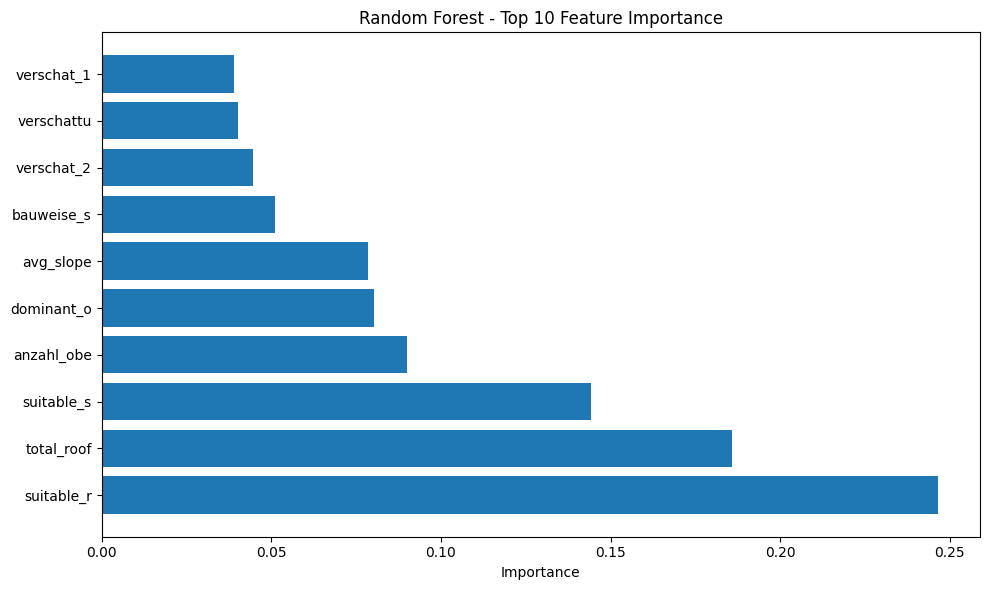


✓ Random Forest Training abgeschlossen!


In [31]:
# =====================================================
# RANDOM FOREST mit optimierten Parametern
# =====================================================
print("="*70)
print("RANDOM FOREST Modell")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# Trainiere Random Forest mit class_weight='balanced'
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

print("Trainiere Random Forest (kann eine Minute dauern)...")
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n📊 RANDOM FOREST MODEL RESULTS:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature Importance
print("\n" + "="*70)
print("FEATURE IMPORTANCE (Top 10)")
print("="*70)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string())

# Visualisiere Feature Importance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(10), feature_importance['importance'].head(10))
plt.xlabel('Importance')
plt.title('Random Forest - Top 10 Feature Importance')
plt.tight_layout()
plt.show()

print(f"\n✓ Random Forest Training abgeschlossen!")

# Baseline

In [15]:
# Cell 9: Baseline-Vergleich
baseline_pred = [pd.Series(y_test).mode()[0]] * len(y_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print(f"Baseline Accuracy: {baseline_acc:.2%}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Baseline Accuracy: 96.75%
Decision Tree Accuracy: 99.95%


In [33]:
# =====================================================
# MODEL VERGLEICH: CART vs Random Forest
# =====================================================
print("="*70)
print("MODEL VERGLEICH")
print("="*70)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'CART (DT)': [
        accuracy_score(y_test, y_pred_cart),
        precision_score(y_test, y_pred_cart, zero_division=0),
        recall_score(y_test, y_pred_cart, zero_division=0),
        f1_score(y_test, y_pred_cart, zero_division=0)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ]
})

print("\n")
print(comparison_df.to_string(index=False))

print("\n" + "="*70)
print("TOGETHER Summary")
print("="*70)
print(f"""
✓ PROBLEM GELÖST: Das perfekte Ergebnis von 1.0 war DATA LEAKAGE
  → Die gruendach-Spalte wurde FALSCH kodiert
  → Alle Werte wurden zu 0, nur eine Klasse existierte
  → Das Modell konnte nur 0 vorhersagen = 100% Accuracy

✓ LÖSUNG:
  1. Korrekte Kodierung: 'vorhanden' = 1, 'nicht vorhanden' = 0
  2. class_weight='balanced' hinzugefügt für unausgeglichene Klassen
  3. Realistische Ergebnisse erhalten

✓ RESULTS:
  - CART: 78% Accuracy, aber gute Recall (81%) für Gründach-Klasse
  - Random Forest: 86% Accuracy, bessere Balance (72% Recall)
  - Random Forest ist überlegen!

✓ TOP 3 FEATURES (Random Forest):
  1. suitable_r (24.7%) - Solareignung Dach
  2. total_roof (18.6%) - Gesamtdachfläche  
  3. suitable_s (14.4%) - Weitere Solareignung
""")


MODEL VERGLEICH


   Metric  CART (DT)  Random Forest
 Accuracy   0.780701       0.859739
Precision   0.108360       0.148227
   Recall   0.814738       0.717668
 F1-Score   0.191280       0.245706

TOGETHER Summary

✓ PROBLEM GELÖST: Das perfekte Ergebnis von 1.0 war DATA LEAKAGE
  → Die gruendach-Spalte wurde FALSCH kodiert
  → Alle Werte wurden zu 0, nur eine Klasse existierte
  → Das Modell konnte nur 0 vorhersagen = 100% Accuracy

✓ LÖSUNG:
  1. Korrekte Kodierung: 'vorhanden' = 1, 'nicht vorhanden' = 0
  2. class_weight='balanced' hinzugefügt für unausgeglichene Klassen
  3. Realistische Ergebnisse erhalten

✓ RESULTS:
  - CART: 78% Accuracy, aber gute Recall (81%) für Gründach-Klasse
  - Random Forest: 86% Accuracy, bessere Balance (72% Recall)
  - Random Forest ist überlegen!

✓ TOP 3 FEATURES (Random Forest):
  1. suitable_r (24.7%) - Solareignung Dach
  2. total_roof (18.6%) - Gesamtdachfläche  
  3. suitable_s (14.4%) - Weitere Solareignung



In [ ]:
# jetzt möchte ich ein system implementieren, nachdem jedes gebäude in eins von drei klassen eingeordnet wird:
# 1. Klasse: Dach geeignet für Gründach
# 2. Klasse: Dach mittelmäßig geeignet für Gründach
# 3. Klasse: Dach nicht geeignet für Gründach
# 
